Menghubungkan ke Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Daftar kolom ditemukan: ['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income', 'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color', 'Price ($)', 'Dealer_No', 'Body Style', 'Phone', 'Dealer_Region']
Berhasil memproses kolom 'Date'.

PROSES SELESAI!
Total Data Mingguan: 105 minggu
Data Training      : 84 minggu
Data Testing       : 21 minggu
Melatih model Holt-Winters...
Melatih model SARIMA dengan auto_arima...
Melatih model Random Forest dengan fitur lag/rolling...
Melatih model LSTM (Deep Learning) dengan early stopping...
Melatih model Prophet...

=== HASIL EVALUASI MODEL (PREDIKSI PENJUALAN MOBIL) ===


,Model,MAE,RMSE,MAPE (%),SMAPE (%),MASE,R²,AIC,BIC
0,Holt-Winters,175.01,203.16,43.81,59.85,2.81,-2.46,733.01,742.74
1,SARIMA,76.12,86.17,24.88,22.86,1.22,0.38,356.92,361.22
2,Random Forest,148.16,169.38,39.27,48.06,2.38,-1.41,N/A,N/A
3,LSTM,100.95,121.71,27.34,32.18,1.62,-0.24,N/A,N/A
4,Prophet,72.37,88.80,22.66,21.68,1.16,0.34,N/A,N/A


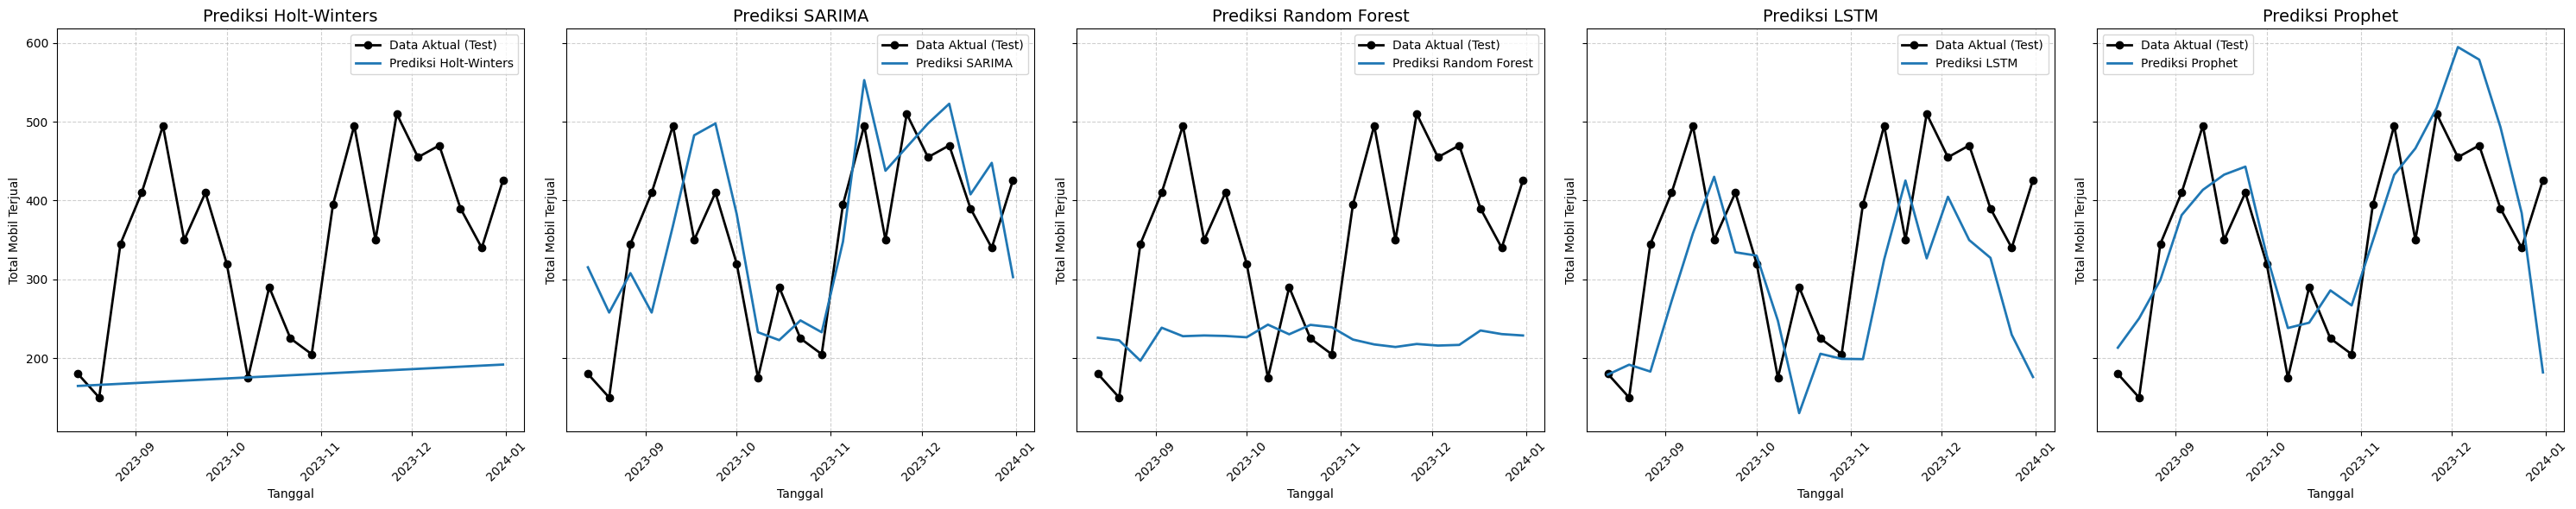

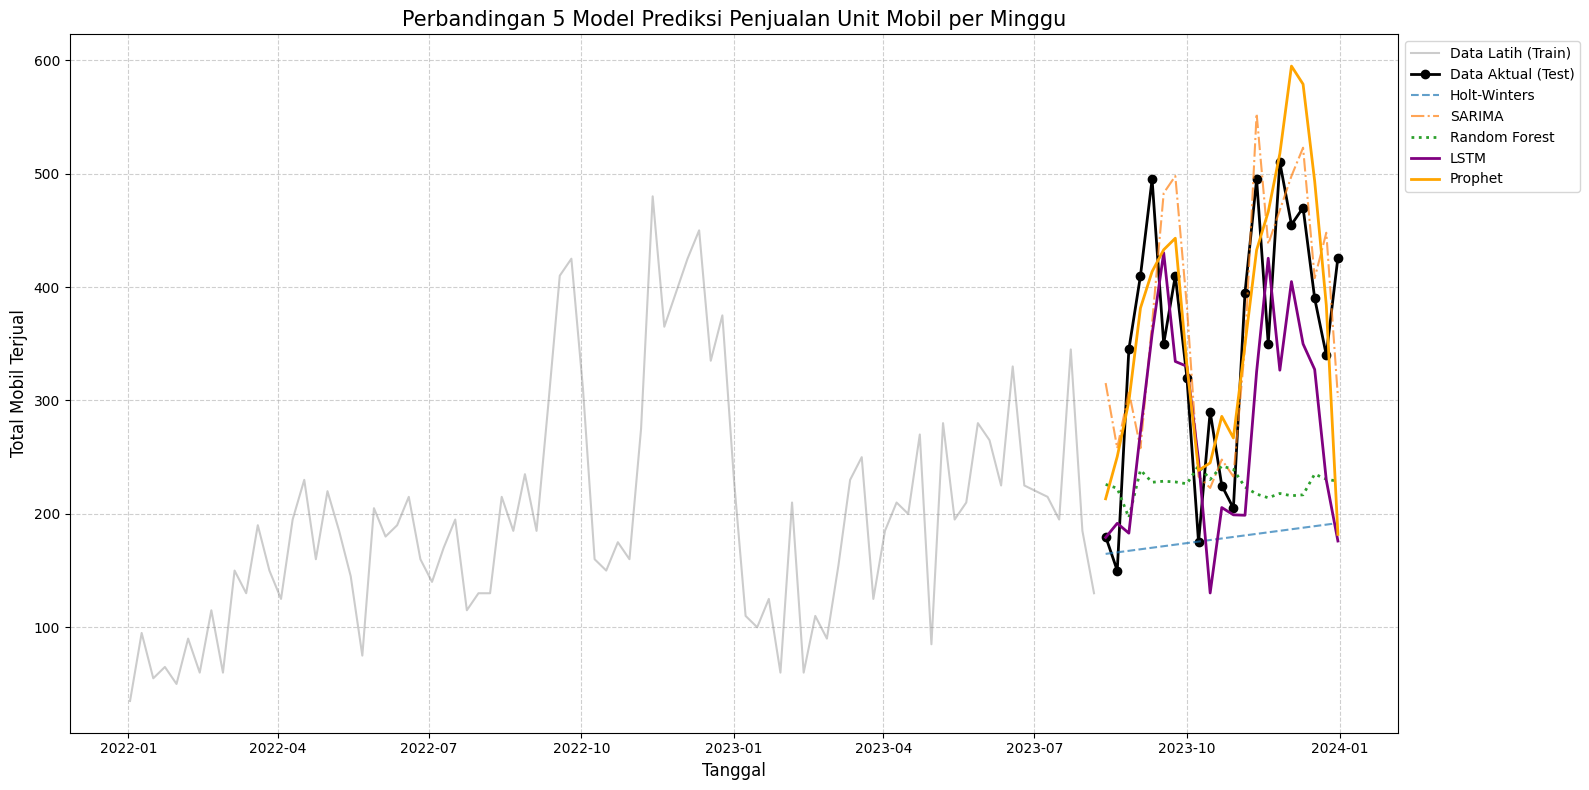


=== ANALISIS RESIDUAL (ERROR DISTRIBUTION) ===


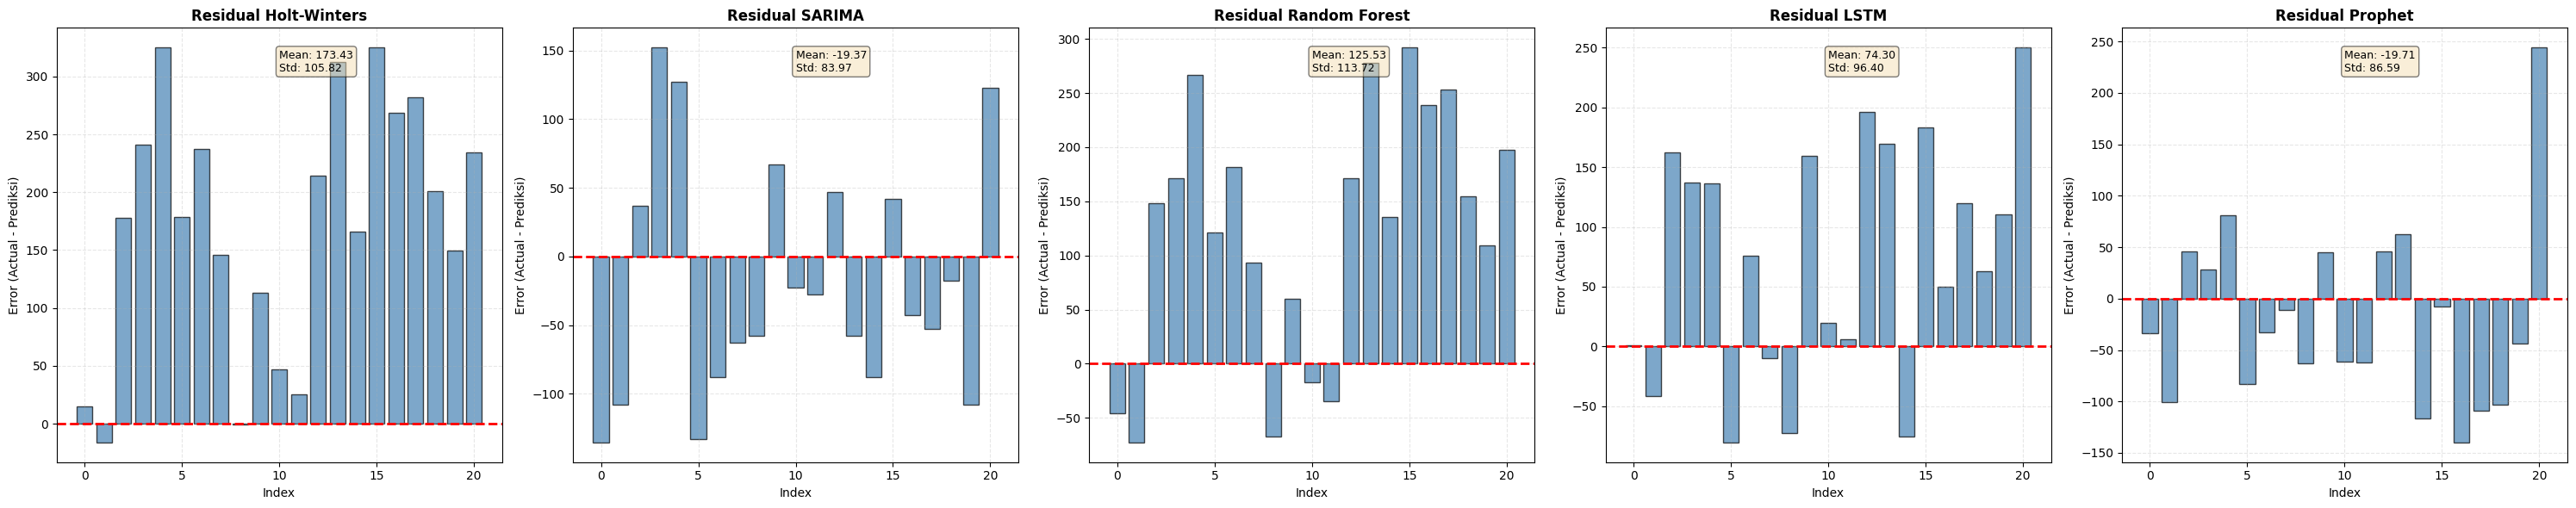


=== RANKING MODEL (SORTED BY SMAPE) ===
        Model  SMAPE (%)    MAE   RMSE    R²
      Prophet      21.68  72.37  88.80  0.34
       SARIMA      22.86  76.12  86.17  0.38
         LSTM      32.18 100.95 121.71 -0.24
Random Forest      48.06 148.16 169.38 -1.41
 Holt-Winters      59.85 175.01 203.16 -2.46


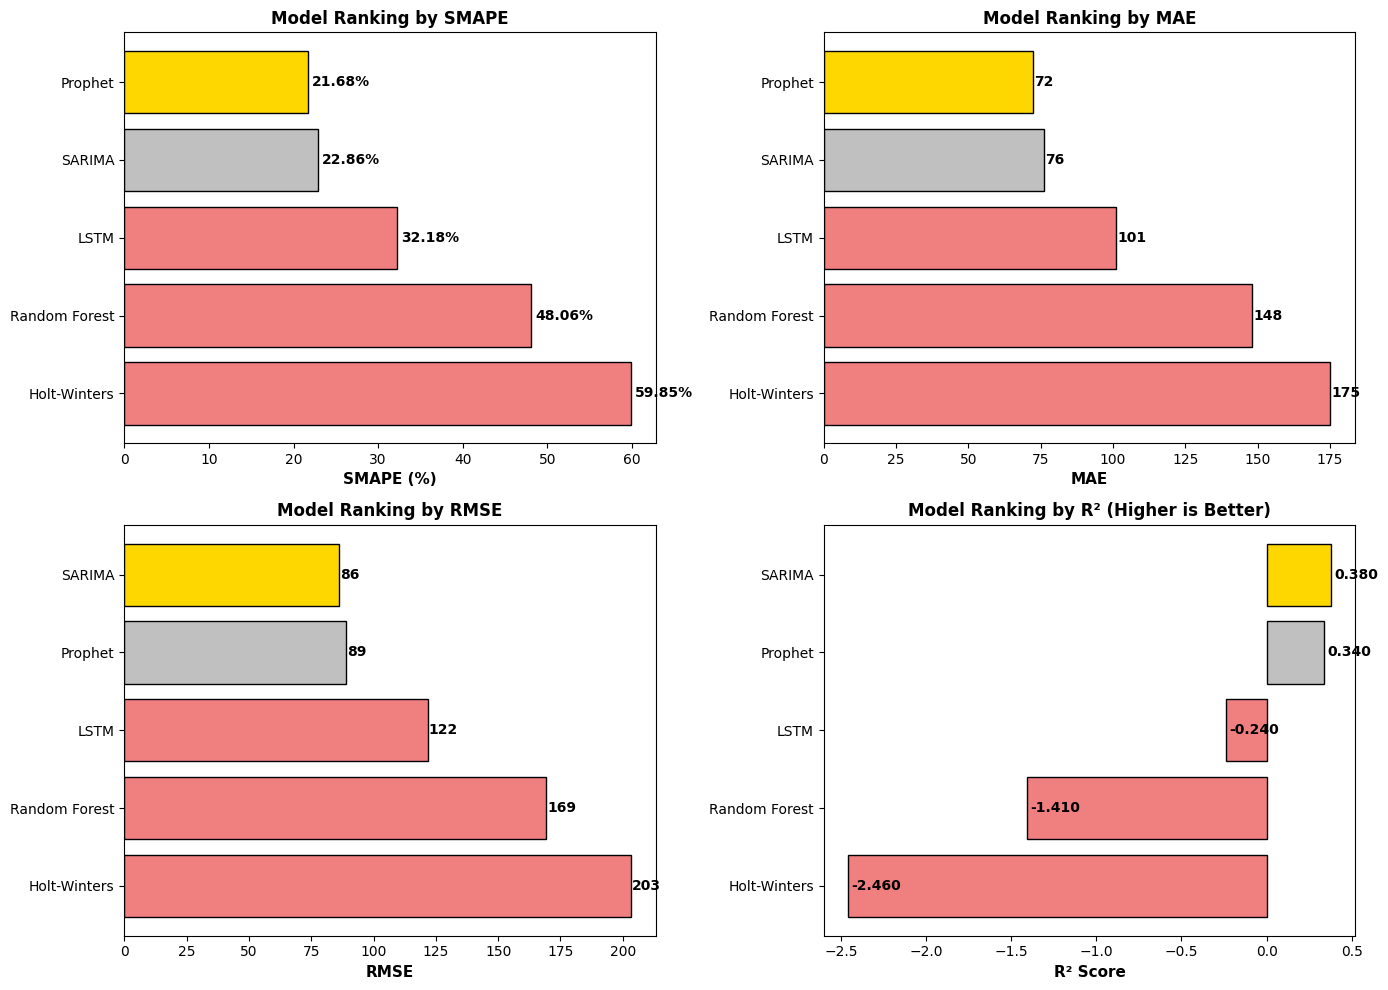


=== CONFUSION MATRIX TREN PENJUALAN ===


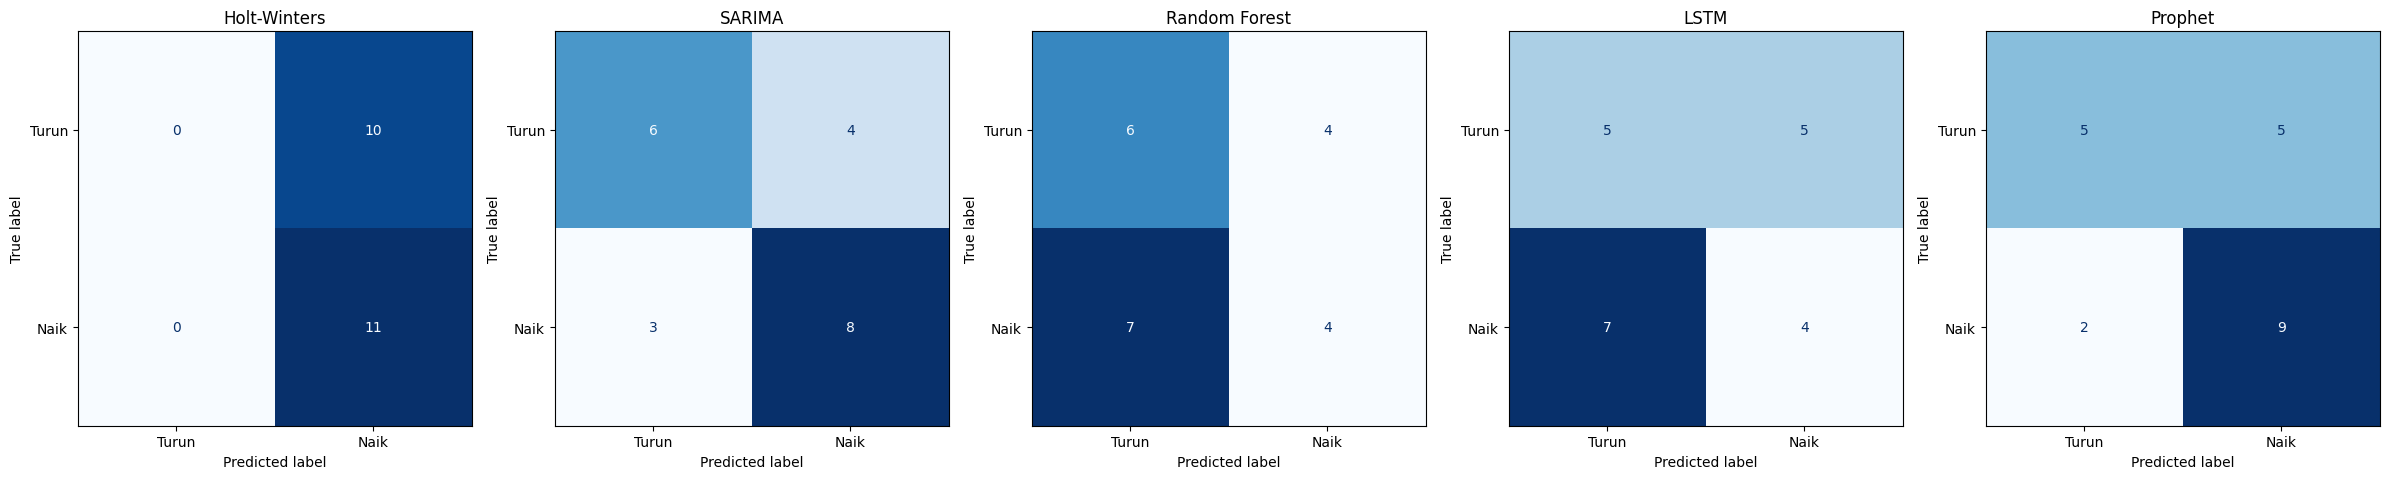

In [5]:
# ==========================================
# 1. INSTALL & IMPORT LIBRARY
# ==========================================
!pip install pmdarima statsmodels scikit-learn matplotlib seaborn pandas numpy tensorflow prophet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
from google.colab import drive, files

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score, confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
import tensorflow as tf

from prophet import Prophet

import warnings
warnings.filterwarnings('ignore')

# Set seed agar hasil konsisten
tf.random.set_seed(42)
np.random.seed(42)

# ==========================================
# 2. MOUNT GOOGLE DRIVE & BACA DATA (CAR SALES FIXED)
# ==========================================
from google.colab import drive
import pandas as pd
import os

print("Menghubungkan ke Google Drive...")
drive.mount('/content/drive')

# SESUAIKAN: Path file Car_sales.csv di Google Drive Anda
file_path = '/content/drive/MyDrive/Colab Notebooks/Car_sales.csv'

if os.path.exists(file_path):
    try:
        # 1. Gunakan encoding='utf-8-sig' untuk menghilangkan karakter \ufeff (BOM)
        # 2. Gunakan sep=None agar pandas mendeteksi sendiri pemisah (koma atau titik koma)
        df = pd.read_csv(file_path, sep=None, engine='python', encoding='utf-8-sig', on_bad_lines='skip')
        
        # Membersihkan spasi pada awalan/akhiran nama kolom
        df.columns = df.columns.str.strip()
        print("Daftar kolom ditemukan:", df.columns.tolist())

        # --- PREPROCESSING KOLOM TANGGAL ---
        # Di dataset mobil, nama kolomnya adalah 'Date' (huruf D kapital)
        if 'Date' in df.columns:
            # Konversi ke format datetime (errors='coerce' akan mengubah format salah menjadi NaT)
            df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
            # Hapus baris yang tanggalnya kosong/error
            df = df.dropna(subset=['Date'])
            print("Berhasil memproses kolom 'Date'.")
        else:
            print("KOLOM 'Date' TIDAK DITEMUKAN. Periksa kembali nama kolom!")

        # --- AGREGASI MINGGUAN (PREDIKSI JUMLAH MOBIL TERJUAL) ---
        # Karena kita ingin memprediksi JUMLAH mobil terjual, kita hitung baris transaksinya menggunakan .size()
        df_daily = df.groupby('Date').size().reset_index(name='quantity')
        df_daily.set_index('Date', inplace=True)

        # Resample menjadi data Mingguan (W) dan isi minggu yang kosong dengan 0
        y = df_daily['quantity'].resample('W').sum().fillna(0)

        # Split Data (80% Train, 20% Test)
        train_size = int(len(y) * 0.8)
        train, test = y.iloc[:train_size], y.iloc[train_size:]

        print(f"\nPROSES SELESAI!")
        print(f"Total Data Mingguan: {len(y)} minggu")
        print(f"Data Training      : {len(train)} minggu")
        print(f"Data Testing       : {len(test)} minggu")

    except Exception as e:
        print(f"Gagal membaca file: {e}")
else:
    print(f"ERROR: File tidak ditemukan di: {file_path}")
# ==========================================
# 3. FUNGSI METRIK EVALUASI
# ==========================================
def smape(y_true, y_pred):
    return np.mean(2.0 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100

def mase(y_true, y_pred, y_train):
    naive_error = np.mean(np.abs(np.diff(y_train)))
    return mean_absolute_error(y_true, y_pred) / naive_error if naive_error != 0 else np.nan

def evaluate_model(name, y_true, y_pred, y_train, aic='N/A', bic='N/A'):
    return {
        'Model': name,
        'MAE': round(mean_absolute_error(y_true, y_pred), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        'MAPE (%)': round(mean_absolute_percentage_error(y_true, y_pred) * 100, 2),
        'SMAPE (%)': round(smape(y_true, y_pred), 2),
        'MASE': round(mase(y_true, y_pred, y_train), 2),
        'R²': round(r2_score(y_true, y_pred), 2),
        'AIC': round(aic, 2) if isinstance(aic, (int, float)) else aic,
        'BIC': round(bic, 2) if isinstance(bic, (int, float)) else bic
    }

metrics_list = []
predictions = pd.DataFrame(index=test.index)
predictions['Aktual'] = test

# ==========================================
# 4. TRAINING & PREDIKSI MODEL (DITINGKATKAN)
# ==========================================

# A. Holt-Winters (Tambahkan seasonal jika data cukup panjang)
print("Melatih model Holt-Winters...")
seasonal_periods = 52 if len(train) >= 52 else None
if seasonal_periods and len(train) >= seasonal_periods * 2:
    hw_model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=seasonal_periods, initialization_method='estimated').fit()
else:
    hw_model = ExponentialSmoothing(train, trend='add', seasonal=None, initialization_method='estimated').fit()
predictions['Holt-Winters'] = hw_model.forecast(len(test))
metrics_list.append(evaluate_model('Holt-Winters', test, predictions['Holt-Winters'], train, hw_model.aic, hw_model.bic))

# B. SARIMA (auto_arima untuk optimalisasi parameter)
print("Melatih model SARIMA dengan auto_arima...")
try:
    from pmdarima import auto_arima
    sarima_arima = auto_arima(train, start_p=0, start_q=0, max_p=3, max_q=3, m=52, start_P=0, start_Q=0, max_P=1, max_Q=1, seasonal=True, d=1, D=1, trace=False, error_action='ignore', suppress_warnings=True, stepwise=True)
    sarima_params = sarima_arima.order
    sarima_seasonal = sarima_arima.seasonal_order
    sarima_model = SARIMAX(train, order=sarima_params, seasonal_order=sarima_seasonal).fit(disp=False)
except Exception as e:
    print(f"auto_arima gagal ({e}); fallback ke default SARIMA.")
    sarima_model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 52)).fit(disp=False)
predictions['SARIMA'] = sarima_model.forecast(len(test))
metrics_list.append(evaluate_model('SARIMA', test, predictions['SARIMA'], train, sarima_model.aic, sarima_model.bic))

# C. Random Forest dengan feature engineering lag/rolling
print("Melatih model Random Forest dengan fitur lag/rolling...")

def make_time_features(series):
    df_feat = series.reset_index().rename(columns={0: 'y'}) if isinstance(series, pd.Series) else series.copy()
    df_feat['Month'] = df_feat['Date'].dt.month
    df_feat['Week'] = df_feat['Date'].dt.isocalendar().week
    for lag in [1, 2, 3, 4, 52]:
        df_feat[f'lag_{lag}'] = df_feat['quantity'].shift(lag)
    df_feat['rolling_4'] = df_feat['quantity'].shift(1).rolling(window=4, min_periods=1).mean()
    df_feat['rolling_12'] = df_feat['quantity'].shift(1).rolling(window=12, min_periods=1).mean()
    return df_feat.dropna()

train_rf = train.reset_index().rename(columns={0:'quantity'})
train_rf['quantity'] = train_rf['quantity'] if 'quantity' in train_rf.columns else train_rf.iloc[:,1]
train_rf = make_time_features(train_rf)

X_train_rf = train_rf[['Month', 'Week', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_52', 'rolling_4', 'rolling_12']]
y_train_rf = train_rf['quantity']

imputed_test = test.reset_index().rename(columns={0:'quantity'})
imputed_test['quantity'] = imputed_test['quantity'] if 'quantity' in imputed_test.columns else imputed_test.iloc[:,1]
combined = pd.concat([train_rf[['Date','quantity']], imputed_test[['Date','quantity']]])
combined = combined.reset_index(drop=True)
combined = make_time_features(combined)
X_test_rf = combined.loc[combined['Date'].isin(test.index), ['Month', 'Week', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_52', 'rolling_4', 'rolling_12']]

rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42).fit(X_train_rf, y_train_rf)

# Buat prediksi iteratif untuk mencegah data leakage dan agar panjang output = test
rf_preds = []
history = train.copy()
for dt in test.index:
    month = dt.month
    week = dt.isocalendar().week
    lag_values = []
    for lag in [1, 2, 3, 4, 52]:
        if len(history) >= lag:
            lag_values.append(history.iloc[-lag])
        else:
            lag_values.append(history.iloc[0])
    rolling_4 = history.shift(1).rolling(window=4, min_periods=1).mean().iloc[-1]
    rolling_12 = history.shift(1).rolling(window=12, min_periods=1).mean().iloc[-1]

    row = pd.DataFrame([[month, week] + lag_values + [rolling_4, rolling_12]],
                       columns=['Month', 'Week', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_52', 'rolling_4', 'rolling_12'])
    pred = rf_model.predict(row)[0]
    rf_preds.append(pred)
    history.loc[dt] = pred

predictions['Random Forest'] = rf_preds
metrics_list.append(evaluate_model('Random Forest', test, predictions['Random Forest'], train))

# D. LSTM (Deep Learning) dengan early stopping dan look_back lebih panjang
print("Melatih model LSTM (Deep Learning) dengan early stopping...")
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))

look_back = 8
X_train_lstm, y_train_lstm = [], []
for i in range(look_back, len(train_scaled)):
    X_train_lstm.append(train_scaled[i-look_back:i, 0])
    y_train_lstm.append(train_scaled[i, 0])
X_train_lstm, y_train_lstm = np.array(X_train_lstm), np.array(y_train_lstm)
X_train_lstm = X_train_lstm.reshape((X_train_lstm.shape[0], X_train_lstm.shape[1], 1))

inputs = y[len(y) - len(test) - look_back:].values.reshape(-1, 1)
inputs = scaler.transform(inputs)

X_test_lstm = []
for i in range(look_back, len(inputs)):
    X_test_lstm.append(inputs[i-look_back:i, 0])
X_test_lstm = np.array(X_test_lstm).reshape((len(test), look_back, 1))

lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(look_back, 1)),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(1)
])
lstm_model.compile(loss='mean_squared_error', optimizer='adam')

from tensorflow.keras.callbacks import EarlyStopping
es = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True, verbose=0)
lstm_model.fit(X_train_lstm, y_train_lstm, epochs=120, batch_size=8, verbose=0, callbacks=[es])

lstm_pred_scaled = lstm_model.predict(X_test_lstm, verbose=0)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)
predictions['LSTM'] = lstm_pred.flatten()
metrics_list.append(evaluate_model('LSTM', test, predictions['LSTM'], train))

# E. Prophet (Meta) dengan seasonality tambahan dan changepoints adaptif
print("Melatih model Prophet...")
train_prophet = train.reset_index().rename(columns={'Date':'ds', 'quantity':'y'})

prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False, changepoint_prior_scale=0.5)
prophet_model.add_seasonality(name='monthly', period=30.5, fourier_order=5)
prophet_model.add_seasonality(name='quarterly', period=91.25, fourier_order=4)
prophet_model.fit(train_prophet)

future = prophet_model.make_future_dataframe(periods=len(test), freq='W')
forecast = prophet_model.predict(future)

predictions['Prophet'] = forecast['yhat'].iloc[-len(test):].values
metrics_list.append(evaluate_model('Prophet', test, predictions['Prophet'], train))

# ==========================================
# 5. MENAMPILKAN HASIL EVALUASI
# ==========================================
df_metrics = pd.DataFrame(metrics_list)
print("\n=== HASIL EVALUASI MODEL (PREDIKSI PENJUALAN MOBIL) ===")
display(df_metrics)

# ==========================================
# 6. GRAFIK PERBANDINGAN PREDIKSI (TERPISAH PER MODEL)
# ==========================================
models_to_plot = ['Holt-Winters', 'SARIMA', 'Random Forest', 'LSTM', 'Prophet']
fig, axes = plt.subplots(1, 5, figsize=(30, 6), sharey=True)

for idx, model in enumerate(models_to_plot):
    axes[idx].plot(test.index, test, label='Data Aktual (Test)', color='black', marker='o', linewidth=2)
    axes[idx].plot(test.index, predictions[model], label=f'Prediksi {model}', linestyle='-', linewidth=2)
    axes[idx].set_title(f'Prediksi {model}', fontsize=14)
    axes[idx].set_xlabel('Tanggal', fontsize=10)
    axes[idx].set_ylabel('Total Mobil Terjual', fontsize=10)
    axes[idx].legend()
    axes[idx].grid(True, linestyle='--', alpha=0.6)
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 8))
plt.plot(train.index, train, label='Data Latih (Train)', color='grey', alpha=0.4)
plt.plot(test.index, test, label='Data Aktual (Test)', color='black', marker='o', linewidth=2)

plt.plot(test.index, predictions['Holt-Winters'], label='Holt-Winters', linestyle='--', alpha=0.7)
plt.plot(test.index, predictions['SARIMA'], label='SARIMA', linestyle='-.', alpha=0.7)
plt.plot(test.index, predictions['Random Forest'], label='Random Forest', linestyle=':', linewidth=2)
plt.plot(test.index, predictions['LSTM'], label='LSTM', color='purple', linestyle='-', linewidth=2)
plt.plot(test.index, predictions['Prophet'], label='Prophet', color='orange', linestyle='-', linewidth=2)

plt.title('Perbandingan 5 Model Prediksi Penjualan Unit Mobil per Minggu', fontsize=15)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Total Mobil Terjual', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ==========================================
# 6B. GRAFIK PERBANDINGAN RESIDUAL ERROR
# ==========================================
print("\n=== ANALISIS RESIDUAL (ERROR DISTRIBUTION) ===")
fig, axes = plt.subplots(1, 5, figsize=(30, 6))

models_to_plot = ['Holt-Winters', 'SARIMA', 'Random Forest', 'LSTM', 'Prophet']
for idx, model in enumerate(models_to_plot):
    residuals = test.values - predictions[model].values
    axes[idx].bar(range(len(residuals)), residuals, alpha=0.7, color='steelblue', edgecolor='black')
    axes[idx].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[idx].set_title(f'Residual {model}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Index', fontsize=10)
    axes[idx].set_ylabel('Error (Actual - Prediksi)', fontsize=10)
    axes[idx].grid(True, linestyle='--', alpha=0.3)
    
    # Tambahkan statistik
    mean_residual = np.mean(residuals)
    std_residual = np.std(residuals)
    axes[idx].text(0.5, 0.95, f'Mean: {mean_residual:.2f}\nStd: {std_residual:.2f}', 
                   transform=axes[idx].transAxes, fontsize=9, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# ==========================================
# 6C. RANKING MODEL BERDASARKAN METRIK
# ==========================================
print("\n=== RANKING MODEL (SORTED BY SMAPE) ===")
ranking = df_metrics[['Model', 'SMAPE (%)', 'MAE', 'RMSE', 'R²']].sort_values('SMAPE (%)')
print(ranking.to_string(index=False))

# Visualisasi ranking
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# SMAPE Ranking
ax1 = axes[0, 0]
smape_sorted = df_metrics.sort_values('SMAPE (%)')
colors = ['gold' if i == 0 else 'silver' if i == 1 else 'lightcoral' for i in range(len(smape_sorted))]
ax1.barh(range(len(smape_sorted)), smape_sorted['SMAPE (%)'], color=colors, edgecolor='black')
ax1.set_yticks(range(len(smape_sorted)))
ax1.set_yticklabels(smape_sorted['Model'])
ax1.set_xlabel('SMAPE (%)', fontsize=11, fontweight='bold')
ax1.set_title('Model Ranking by SMAPE', fontsize=12, fontweight='bold')
ax1.invert_yaxis()
for i, v in enumerate(smape_sorted['SMAPE (%)']):
    ax1.text(v + 0.5, i, f'{v:.2f}%', va='center', fontweight='bold')

# MAE Ranking
ax2 = axes[0, 1]
mae_sorted = df_metrics.sort_values('MAE')
colors = ['gold' if i == 0 else 'silver' if i == 1 else 'lightcoral' for i in range(len(mae_sorted))]
ax2.barh(range(len(mae_sorted)), mae_sorted['MAE'], color=colors, edgecolor='black')
ax2.set_yticks(range(len(mae_sorted)))
ax2.set_yticklabels(mae_sorted['Model'])
ax2.set_xlabel('MAE', fontsize=11, fontweight='bold')
ax2.set_title('Model Ranking by MAE', fontsize=12, fontweight='bold')
ax2.invert_yaxis()
for i, v in enumerate(mae_sorted['MAE']):
    ax2.text(v + 0.5, i, f'{v:.0f}', va='center', fontweight='bold')

# RMSE Ranking
ax3 = axes[1, 0]
rmse_sorted = df_metrics.sort_values('RMSE')
colors = ['gold' if i == 0 else 'silver' if i == 1 else 'lightcoral' for i in range(len(rmse_sorted))]
ax3.barh(range(len(rmse_sorted)), rmse_sorted['RMSE'], color=colors, edgecolor='black')
ax3.set_yticks(range(len(rmse_sorted)))
ax3.set_yticklabels(rmse_sorted['Model'])
ax3.set_xlabel('RMSE', fontsize=11, fontweight='bold')
ax3.set_title('Model Ranking by RMSE', fontsize=12, fontweight='bold')
ax3.invert_yaxis()
for i, v in enumerate(rmse_sorted['RMSE']):
    ax3.text(v + 0.5, i, f'{v:.0f}', va='center', fontweight='bold')

# R² Ranking
ax4 = axes[1, 1]
r2_sorted = df_metrics.sort_values('R²', ascending=False)
colors = ['gold' if i == 0 else 'silver' if i == 1 else 'lightcoral' for i in range(len(r2_sorted))]
ax4.barh(range(len(r2_sorted)), r2_sorted['R²'], color=colors, edgecolor='black')
ax4.set_yticks(range(len(r2_sorted)))
ax4.set_yticklabels(r2_sorted['Model'])
ax4.set_xlabel('R² Score', fontsize=11, fontweight='bold')
ax4.set_title('Model Ranking by R² (Higher is Better)', fontsize=12, fontweight='bold')
ax4.invert_yaxis()
for i, v in enumerate(r2_sorted['R²']):
    ax4.text(v + 0.02, i, f'{v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# ==========================================
# 7. CONFUSION MATRIX (KLASIFIKASI TREN NAIK/TURUN)
# ==========================================
print("\n=== CONFUSION MATRIX TREN PENJUALAN ===")

last_train_val = train.iloc[-1]
actual_shifted = np.append([last_train_val], test.values[:-1])
actual_trend = (test.values > actual_shifted).astype(int) 

models_to_plot = ['Holt-Winters', 'SARIMA', 'Random Forest', 'LSTM', 'Prophet']
fig, axes = plt.subplots(1, 5, figsize=(24, 5))

for idx, model in enumerate(models_to_plot):
    pred_shifted = np.append([last_train_val], predictions[model].values[:-1])
    pred_trend = (predictions[model].values > pred_shifted).astype(int)

    cm = confusion_matrix(actual_trend, pred_trend, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Turun', 'Naik'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f'{model}')

plt.tight_layout()
plt.show()